# 📚 N-gram Language Models with Smoothing
### Laplace Smoothing · Kneser-Ney Smoothing · Perplexity — From Scratch

---

**What you'll learn in this notebook:**
1. What an N-gram Language Model is and *why* it works
2. How to estimate probabilities using Maximum Likelihood Estimation (MLE)
3. The **zero-probability problem** and why smoothing is necessary
4. **Laplace (Add-1) Smoothing** — mechanics + worked example
5. **Kneser-Ney Smoothing** — the state-of-the-art classic, step by step
6. **Perplexity** — how we measure how "surprised" a model is, computed by hand
7. Full Python implementation with visualisations

---


## 1. 🧠 Intuition — What is a Language Model?

A **Language Model (LM)** assigns a probability to a sequence of words:

$$P(w_1, w_2, \ldots, w_n)$$

**Why?** It lets us answer: *"How likely is this sentence?"*

Using the **Chain Rule of Probability**:

$$P(w_1 w_2 \cdots w_n) = P(w_1)\;P(w_2|w_1)\;P(w_3|w_1 w_2)\;\cdots$$

The problem: conditioning on the **entire history** is computationally intractable.

### The Markov Assumption
We approximate by assuming only the last **(n-1)** words matter:

$$P(w_i \mid w_1 \cdots w_{i-1}) \approx P(w_i \mid w_{i-n+1} \cdots w_{i-1})$$

| Model | Condition on | Example |
|-------|-------------|---------|
| **Unigram** | nothing | P(dog) |
| **Bigram** | 1 previous word | P(dog \| the) |
| **Trigram** | 2 previous words | P(dog \| chase the) |
| **N-gram** | n-1 previous words | general case |


## 2. 📊 Maximum Likelihood Estimation (MLE)

We estimate probabilities by **counting** in a training corpus.

### Bigram MLE formula:

$$P_{MLE}(w_i \mid w_{i-1}) = \frac{C(w_{i-1},\; w_i)}{C(w_{i-1})}$$

Where $C(\cdot)$ = count of the sequence in training data.

### Example:
Corpus: *"the cat sat on the mat the cat ate"*

- $C(\text{the, cat}) = 2$, $C(\text{the}) = 3$
- $P_{MLE}(\text{cat} \mid \text{the}) = 2/3 \approx 0.667$


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict, Counter
from itertools import tee
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette ──────────────────────────────────────────────────────────
C = dict(blue="#2563EB", green="#16A34A", red="#DC2626",
         orange="#EA580C", purple="#7C3AED", gray="#6B7280",
         light="#F1F5F9", dark="#1E293B")

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1", "axes.grid": True,
    "grid.color": "#E2E8F0", "grid.linewidth": 0.8,
    "font.family": "DejaVu Sans", "font.size": 11,
})

# ── Corpus ─────────────────────────────────────────────────────────────────
corpus = [
    "<s> the cat sat on the mat </s>",
    "<s> the cat ate the rat </s>",
    "<s> the rat sat on the mat </s>",
    "<s> the dog chased the cat </s>",
    "<s> the cat ran away </s>",
]

def tokenise(sentences):
    return [s.split() for s in sentences]

tokens = tokenise(corpus)
print("Training corpus (tokenised):")
for i, sent in enumerate(tokens):
    print(f"  [{i+1}] {' '.join(sent)}")


Training corpus (tokenised):
  [1] <s> the cat sat on the mat </s>
  [2] <s> the cat ate the rat </s>
  [3] <s> the rat sat on the mat </s>
  [4] <s> the dog chased the cat </s>
  [5] <s> the cat ran away </s>


In [15]:
def build_ngram_counts(token_sents, n):
    """Build n-gram and (n-1)-gram count dictionaries."""
    ngram_counts   = defaultdict(int)
    context_counts = defaultdict(int)  # (n-1)-gram counts

    for sent in token_sents:
        for i in range(len(sent) - n + 1):
            ngram   = tuple(sent[i : i+n])
            context = tuple(sent[i : i+n-1])
            ngram_counts[ngram]   += 1
            context_counts[context] += 1

    # Also count unigrams
    unigram_counts = defaultdict(int)
    for sent in token_sents:
        for w in sent:
            unigram_counts[(w,)] += 1

    return ngram_counts, context_counts, unigram_counts

bigram_counts, unigram_ctx, unigram_counts = build_ngram_counts(tokens, 2)
trigram_counts, bigram_ctx, _              = build_ngram_counts(tokens, 3)

print("── Top Bigram counts ────────────────────────────────")
for bg, cnt in sorted(bigram_counts.items(), key=lambda x: -x[1])[:10]:
    print(f"  {bg[0]:12s} → {bg[1]:12s}  count = {cnt}")


── Top Bigram counts ────────────────────────────────
  <s>          → the           count = 5
  the          → cat           count = 4
  sat          → on            count = 2
  on           → the           count = 2
  the          → mat           count = 2
  mat          → </s>          count = 2
  the          → rat           count = 2
  cat          → sat           count = 1
  cat          → ate           count = 1
  ate          → the           count = 1


In [16]:
def mle_bigram_prob(word, context, bigram_counts, unigram_counts):
    """MLE bigram probability P(word | context)."""
    num = bigram_counts.get((context, word), 0)
    den = unigram_counts.get((context,), 0)
    return num / den if den > 0 else 0.0

# Demo
examples = [("cat", "the"), ("sat", "cat"), ("flew", "cat")]
print(f"{'P(word | context)':<30} {'Numerator':>10} {'Denominator':>12} {'Probability':>12}")
print("─" * 70)
for word, ctx in examples:
    num = bigram_counts.get((ctx, word), 0)
    den = unigram_counts.get((ctx,), 0)
    p   = num / den if den > 0 else 0.0
    tag = "  ← ZERO! 🚨" if p == 0 else ""
    print(f"  P({word:8s} | {ctx:8s})   {num:>10}   {den:>10}   {p:>12.4f}{tag}")


P(word | context)               Numerator  Denominator  Probability
──────────────────────────────────────────────────────────────────────
  P(cat      | the     )            4            9         0.4444
  P(sat      | cat     )            1            4         0.2500
  P(flew     | cat     )            0            4         0.0000  ← ZERO! 🚨


## 3. 🚨 The Zero-Probability Problem

If a bigram **never appeared** in training, MLE gives it probability **0**.

This causes two disasters:

1. **Any sentence containing that bigram gets probability 0**, even if it's perfectly grammatical.
2. **Perplexity becomes ∞** (division by zero in log space).

**Example:** `P(flew | cat) = 0/3 = 0`  
Even though "the cat flew away" is a valid English sentence!

### Solution: **Smoothing** — steal a little probability mass from seen events and give it to unseen ones.


## 4. 🔵 Laplace (Add-1) Smoothing

The simplest fix: **pretend every n-gram was seen at least once** by adding 1 to every count.

### Formula:

$$P_{Laplace}(w_i \mid w_{i-1}) = \frac{C(w_{i-1},\; w_i) + 1}{C(w_{i-1}) + V}$$

Where $V$ = vocabulary size (number of unique words).

### Intuition:
- Numerator: raw count + 1 (so no zero counts)
- Denominator: normalised so all probabilities sum to 1

### General Add-k Smoothing:

$$P_{Add-k}(w_i \mid w_{i-1}) = \frac{C(w_{i-1},\; w_i) + k}{C(w_{i-1}) + k \cdot V}$$

$k=1$ → Laplace; $k < 1$ → Lidstone smoothing.


In [21]:
def laplace_bigram_prob(word, context, bigram_counts, unigram_counts, vocab, k=1):
    """Add-k smoothed bigram probability."""
    V   = len(vocab)
    num = bigram_counts.get((context, word), 0) + k
    den = unigram_counts.get((context,), 0)  + k * V
    return num / den

# Build vocabulary
vocab = set()
for sent in tokens:
    vocab.update(sent)
V = len(vocab)
print(f"Vocabulary size V = {V}")
print(f"Words: {sorted(vocab)}\n")

# Compare MLE vs Laplace
print(f"{'Bigram':<28} {'MLE':>10} {'Laplace':>10}  Change")
print("─" * 60)
test_cases = [
    ("the", "cat"), ("cat", "sat"), ("cat", "ate"),
    ("cat", "flew"),  # unseen
    ("the", "unicorn"),  # unseen word
]
for ctx, word in test_cases:
    mle_p = mle_bigram_prob(word, ctx, bigram_counts, unigram_counts)
    lap_p = laplace_bigram_prob(word, ctx, bigram_counts, unigram_counts, vocab)
    tag = "✓ fixed!" if mle_p == 0 and lap_p > 0 else ""
    print(f"  P({word:10s} | {ctx:8s})  {mle_p:>10.5f}  {lap_p:>10.5f}  {tag}")

Vocabulary size V = 13
Words: ['</s>', '<s>', 'ate', 'away', 'cat', 'chased', 'dog', 'mat', 'on', 'ran', 'rat', 'sat', 'the']

Bigram                              MLE    Laplace  Change
────────────────────────────────────────────────────────────
  P(cat        | the     )     0.44444     0.22727  
  P(sat        | cat     )     0.25000     0.11765  
  P(ate        | cat     )     0.25000     0.11765  
  P(flew       | cat     )     0.00000     0.05882  ✓ fixed!
  P(unicorn    | the     )     0.00000     0.04545  ✓ fixed!


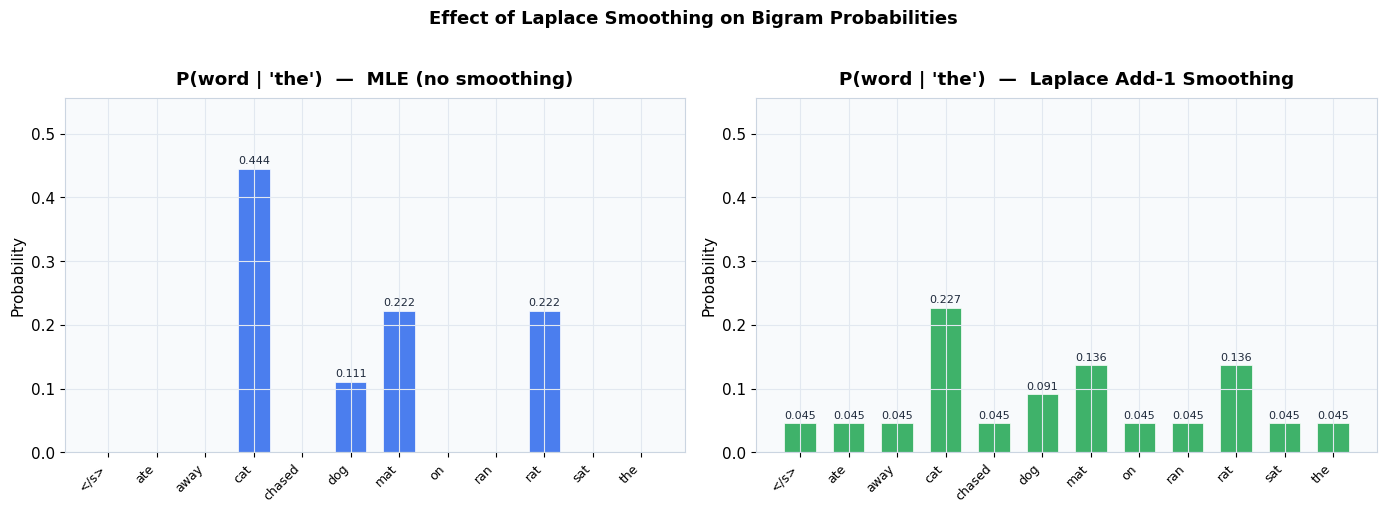

Zero probabilities in MLE: 8   →  After Laplace: 0


In [18]:
# ── Visualise: probability distribution before/after Laplace ─────────────
context_word = "the"
all_words_sorted = sorted(vocab - {"<s>"})

mle_probs    = [mle_bigram_prob(w, context_word, bigram_counts, unigram_counts) for w in all_words_sorted]
laplace_probs = [laplace_bigram_prob(w, context_word, bigram_counts, unigram_counts, vocab) for w in all_words_sorted]

x = np.arange(len(all_words_sorted))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, title, colour in zip(
    axes,
    [mle_probs, laplace_probs],
    ["MLE (no smoothing)", "Laplace Add-1 Smoothing"],
    [C["blue"], C["green"]],
):
    bars = ax.bar(x, probs, width=0.65, color=colour, alpha=0.82, edgecolor="white", linewidth=0.6)
    ax.set_xticks(x); ax.set_xticklabels(all_words_sorted, rotation=45, ha="right", fontsize=9)
    ax.set_title(f"P(word | 'the')  —  {title}", fontweight="bold", pad=10)
    ax.set_ylabel("Probability")
    ax.set_ylim(0, max(max(mle_probs), max(laplace_probs)) * 1.25)
    for bar, p in zip(bars, probs):
        if p > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{p:.3f}", ha="center", va="bottom", fontsize=8, color=C["dark"])

plt.suptitle("Effect of Laplace Smoothing on Bigram Probabilities", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/tmp/laplace.png", dpi=150, bbox_inches="tight")
plt.show()
print("Zero probabilities in MLE:", mle_probs.count(0.0),
      "  →  After Laplace:", laplace_probs.count(0.0))


### ⚠️ Laplace's Weakness

Laplace adds 1 to **every** possible n-gram — including the billions that are truly garbage.  
For a typical vocabulary of 50 000 words, the bigram table has **2.5 billion** entries.  
Adding 1 to all of them **steals too much mass** from observed events.

This is why practitioners use better smoothing methods like **Kneser-Ney**.


## 5. 🟣 Kneser-Ney Smoothing

Kneser-Ney (KN) is the gold-standard classical smoothing method. It has two key innovations:

### Innovation 1 — Absolute Discounting
Instead of adding counts, **subtract a fixed discount** $d$ (≈ 0.75) from every non-zero count:

$$P_{KN}(w_i \mid w_{i-1}) = \frac{\max(C(w_{i-1}, w_i) - d,\; 0)}{C(w_{i-1})} + \lambda(w_{i-1})\; P_{cont}(w_i)$$

### Innovation 2 — Continuation Probability
The lower-order distribution isn't just $P(w_i)$ — it's a smarter estimate:

$$P_{cont}(w_i) = \frac{|\{v : C(v, w_i) > 0\}|}{\sum_{w} |\{v : C(v, w) > 0\}|}$$

This counts **how many unique contexts** word $w_i$ appears in, not how often it appears overall.

**Intuition:** "San Francisco" — *Francisco* is very frequent but *only* after *San*.  
Its continuation count is **low** ⟹ lower-order probability is low ⟹ model is less likely to predict it standalone.

### The λ (back-off weight) — ensures probabilities sum to 1:

$$\lambda(w_{i-1}) = \frac{d \cdot |\{w : C(w_{i-1}, w) > 0\}|}{C(w_{i-1})}$$


In [19]:
def build_kneser_ney(token_sents, discount=0.75):
    """
    Build Kneser-Ney smoothed bigram model.
    Returns a callable: kn_prob(word, context)
    """
    bigram_c  = defaultdict(int)   # C(w_{i-1}, w_i)
    unigram_c = defaultdict(int)   # C(w_{i-1})

    for sent in token_sents:
        for i in range(len(sent) - 1):
            w_prev, w_curr = sent[i], sent[i+1]
            bigram_c[(w_prev, w_curr)] += 1
            unigram_c[w_prev] += 1

    # ── Continuation counts ─────────────────────────────────────────────────
    # For each word w, count unique LEFT contexts: |{v : C(v,w) > 0}|
    left_contexts = defaultdict(set)
    for (w_prev, w_curr) in bigram_c:
        left_contexts[w_curr].add(w_prev)

    cont_count   = {w: len(ctxs) for w, ctxs in left_contexts.items()}
    total_bigram_types = sum(cont_count.values())   # denominator for P_cont

    def p_cont(word):
        """Continuation probability (lower-order estimate)."""
        return cont_count.get(word, 0) / total_bigram_types if total_bigram_types > 0 else 0

    # ── Back-off weight λ ───────────────────────────────────────────────────
    def lambda_weight(context):
        n_types_after_ctx = sum(1 for (c, w) in bigram_c if c == context)
        denom = unigram_c.get(context, 0)
        return (discount * n_types_after_ctx / denom) if denom > 0 else 0

    # ── Main KN probability ─────────────────────────────────────────────────
    def kn_prob(word, context):
        c_ctx_word = bigram_c.get((context, word), 0)
        c_ctx      = unigram_c.get(context, 0)

        if c_ctx == 0:
            return p_cont(word)    # full back-off

        discounted = max(c_ctx_word - discount, 0) / c_ctx
        lam        = lambda_weight(context)
        return discounted + lam * p_cont(word)

    return kn_prob, p_cont, lambda_weight, bigram_c, unigram_c, cont_count

kn_prob, p_cont, lambda_w, bg_c, uni_c, cont_c = build_kneser_ney(tokens)

print("── Continuation counts (unique left contexts per word) ──────────────")
for w, cc in sorted(cont_c.items(), key=lambda x: -x[1]):
    print(f"  {w:12s}  left-contexts = {cc}")


── Continuation counts (unique left contexts per word) ──────────────
  the           left-contexts = 4
  </s>          left-contexts = 4
  sat           left-contexts = 2
  cat           left-contexts = 1
  on            left-contexts = 1
  mat           left-contexts = 1
  ate           left-contexts = 1
  rat           left-contexts = 1
  dog           left-contexts = 1
  chased        left-contexts = 1
  ran           left-contexts = 1
  away          left-contexts = 1


In [22]:
# ── Step-by-step worked example ────────────────────────────────────────────
print("=" * 65)
print("  WORKED EXAMPLE: P_KN(cat | the)")
print("=" * 65)

word, ctx = "cat", "the"
d = 0.75

c_ctx_word = bg_c.get((ctx, word), 0)
c_ctx      = uni_c.get(ctx, 0)
n_types    = sum(1 for (c, w) in bg_c if c == ctx)
lam        = d * n_types / c_ctx if c_ctx > 0 else 0
pc         = p_cont(word)

print(f"""
  C(the, cat)          = {c_ctx_word}""")
print(f"  C(the)               = {c_ctx}")
print(f"  discount d           = {d}")
print(f"  max(C-d, 0) / C(ctx) = max({c_ctx_word}-{d}, 0) / {c_ctx} = {max(c_ctx_word-d,0)/c_ctx:.5f}")
print(f"""
  |types after 'the'|  = {n_types}""")
print(f"  λ(the)               = {d} × {n_types} / {c_ctx}          = {lam:.5f}")
print(f"""
  P_cont(cat)          = {cont_c.get(word,0)} / {sum(cont_c.values())} = {pc:.5f}""")
print(f"""
  P_KN(cat|the)        = {max(c_ctx_word-d,0)/c_ctx:.5f} + {lam:.5f} × {pc:.5f}""")
print(f"                       = {kn_prob(word, ctx):.5f}")
print()

# Compare all three methods
print(f"""
{'Bigram':<28} {'MLE':>10} {'Laplace':>10} {'Kneser-Ney':>12}""")
print("─" * 65)
for ctx_, word_ in test_cases:
    mle_p = mle_bigram_prob(word_, ctx_, bigram_counts, unigram_counts)
    lap_p = laplace_bigram_prob(word_, ctx_, bigram_counts, unigram_counts, vocab)
    kn_p  = kn_prob(word_, ctx_)
    print(f"  P({word_:10s} | {ctx_:8s})  {mle_p:>10.5f}  {lap_p:>10.5f}  {kn_p:>12.5f}")

  WORKED EXAMPLE: P_KN(cat | the)

  C(the, cat)          = 4
  C(the)               = 9
  discount d           = 0.75
  max(C-d, 0) / C(ctx) = max(4-0.75, 0) / 9 = 0.36111

  |types after 'the'|  = 4
  λ(the)               = 0.75 × 4 / 9          = 0.33333

  P_cont(cat)          = 1 / 19 = 0.05263

  P_KN(cat|the)        = 0.36111 + 0.33333 × 0.05263
                       = 0.37865


Bigram                              MLE    Laplace   Kneser-Ney
─────────────────────────────────────────────────────────────────
  P(cat        | the     )     0.44444     0.22727       0.37865
  P(sat        | cat     )     0.25000     0.11765       0.14145
  P(ate        | cat     )     0.25000     0.11765       0.10197
  P(flew       | cat     )     0.00000     0.05882       0.00000
  P(unicorn    | the     )     0.00000     0.04545       0.00000


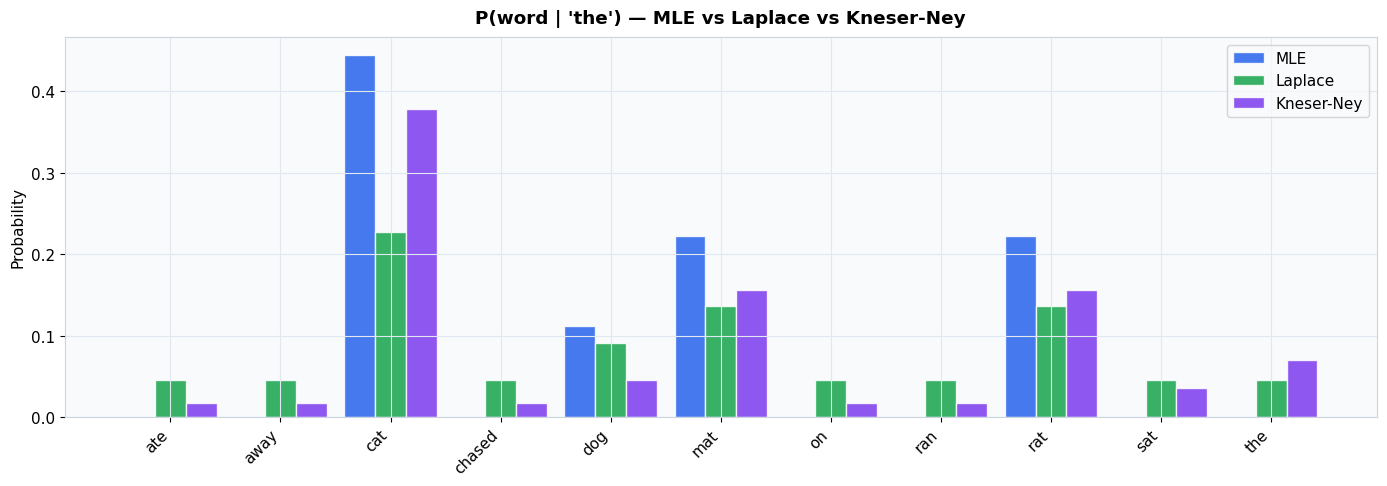

In [25]:
# ── Visual comparison of all three methods ─────────────────────────────────
context_word = "the"
words_plot   = sorted(vocab - {"<s>", "</s>"})

mle_p_list = [mle_bigram_prob(w, context_word, bigram_counts, unigram_counts) for w in words_plot]
lap_p_list = [laplace_bigram_prob(w, context_word, bigram_counts, unigram_counts, vocab) for w in words_plot]
kn_p_list  = [kn_prob(w, context_word) for w in words_plot]

x = np.arange(len(words_plot)); width = 0.28
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, mle_p_list, width, label="MLE",        color=C["blue"],   alpha=0.85, edgecolor="white")
ax.bar(x,         lap_p_list, width, label="Laplace",    color=C["green"],  alpha=0.85, edgecolor="white")
ax.bar(x + width, kn_p_list,  width, label="Kneser-Ney", color=C["purple"], alpha=0.85, edgecolor="white")

ax.set_xticks(x); ax.set_xticklabels(words_plot, rotation=45, ha="right")
ax.set_ylabel("Probability"); ax.set_title(f"P(word | '{context_word}') — MLE vs Laplace vs Kneser-Ney", fontweight="bold", pad=10)
ax.legend(fontsize=11)
plt.tight_layout(); plt.savefig("/tmp/comparison.png", dpi=150, bbox_inches="tight"); plt.show()


## 6. 📐 Perplexity — Measuring Model Quality

**Perplexity (PP)** measures how *surprised* the model is by a test sentence.

Lower perplexity = better model (less surprised = model fits data well).

### Formula:

$$PP(W) = P(w_1 w_2 \cdots w_N)^{-1/N} = \left(\prod_{i=1}^{N} P(w_i \mid w_{i-1})\right)^{-1/N}$$

In log space (numerically stable):

$$\log PP(W) = -\frac{1}{N} \sum_{i=1}^{N} \log_2 P(w_i \mid w_{i-1})$$

$$PP(W) = 2^{\,-\frac{1}{N}\sum \log_2 P}$$

### Intuition:
- PP = **effective branching factor** — at each word, the model is as confused as if it had to choose uniformly from PP words.
- PP of 1 = perfect predictor (always knows next word)
- PP = V = completely random (uniform over vocabulary)


In [29]:
def sentence_perplexity(sentence_tokens, prob_fn, verbose=True):
    """
    Compute bigram perplexity of a sentence.
    sentence_tokens: list of tokens including <s> and </s>
    prob_fn: callable(word, context) → probability
    """
    log_prob_sum = 0.0
    N = 0
    steps = []

    for i in range(1, len(sentence_tokens)):
        word    = sentence_tokens[i]
        context = sentence_tokens[i-1]
        p       = prob_fn(word, context)
        # avoid log(0)
        p_safe  = max(p, 1e-10)
        lp      = np.log2(p_safe)
        log_prob_sum += lp
        N += 1
        steps.append((context, word, p, lp))

    pp = 2 ** (-log_prob_sum / N)
    if verbose:
        print(f"  {'Context':10s} → {'Word':10s}   {'P(w|ctx)':>12}   {'log2 P':>10}")
        print("  " + "─" * 55)
        for ctx, w, p, lp in steps:
            print(f"  {ctx:10s} → {w:10s}   {p:>12.6f}   {lp:>10.4f}")
        print(f"""
  N = {N}""")
        print(f"  Σ log₂P = {log_prob_sum:.4f}")
        print(f"  Avg log₂P = {log_prob_sum/N:.4f}")
        print(f"  Perplexity = 2^(-{log_prob_sum/N:.4f}) = {pp:.4f}")
    return pp

test_sentence = "<s> the cat sat on the mat </s>".split()
print("─" * 60)
print("TEST SENTENCE:", " ".join(test_sentence))
print("─" * 60)
print(f"""
── MLE Perplexity ─────────────────────────────────────────────────────────────────────────────────────""")
pp_mle = sentence_perplexity(
    test_sentence,
    lambda w, c: mle_bigram_prob(w, c, bigram_counts, unigram_counts)
)

print(f"""
── Laplace Perplexity ─────────────────────────────────────────────────────────────────────────────────────""")
pp_lap = sentence_perplexity(
    test_sentence,
    lambda w, c: laplace_bigram_prob(w, c, bigram_counts, unigram_counts, vocab)
)

print(f"""
── Kneser-Ney Perplexity ─────────────────────────────────────────────────────────────────────────────────────""")
pp_kn = sentence_perplexity(test_sentence, kn_prob)


────────────────────────────────────────────────────────────
TEST SENTENCE: <s> the cat sat on the mat </s>
────────────────────────────────────────────────────────────

── MLE Perplexity ─────────────────────────────────────────────────────────────────────────────────────
  Context    → Word             P(w|ctx)       log2 P
  ───────────────────────────────────────────────────────
  <s>        → the              1.000000       0.0000
  the        → cat              0.444444      -1.1699
  cat        → sat              0.250000      -2.0000
  sat        → on               1.000000       0.0000
  on         → the              1.000000       0.0000
  the        → mat              0.222222      -2.1699
  mat        → </s>             1.000000       0.0000

  N = 7
  Σ log₂P = -5.3399
  Avg log₂P = -0.7628
  Perplexity = 2^(--0.7628) = 1.6968

── Laplace Perplexity ─────────────────────────────────────────────────────────────────────────────────────
  Context    → Word             P(w|ctx

In [30]:
# ── Perplexity on an UNSEEN sentence ───────────────────────────────────────
unseen = "<s> the dog sat on the mat </s>".split()
print("━" * 60)
print("UNSEEN SENTENCE:", " ".join(unseen))
print("━" * 60)

pp_mle_u = sentence_perplexity(
    unseen,
    lambda w, c: mle_bigram_prob(w, c, bigram_counts, unigram_counts),
    verbose=True
)
print(f"MLE Perplexity = {pp_mle_u:.2f}  (inf if any P=0)")

print("── KN Perplexity on unseen sentence ────────────────────────")
pp_kn_u = sentence_perplexity(unseen, kn_prob, verbose=False)
print(f"KN Perplexity = {pp_kn_u:.4f}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
UNSEEN SENTENCE: <s> the dog sat on the mat </s>
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Context    → Word             P(w|ctx)       log2 P
  ───────────────────────────────────────────────────────
  <s>        → the              1.000000       0.0000
  the        → dog              0.111111      -3.1699
  dog        → sat              0.000000     -33.2193
  sat        → on               1.000000       0.0000
  on         → the              1.000000       0.0000
  the        → mat              0.222222      -2.1699
  mat        → </s>             1.000000       0.0000

  N = 7
  Σ log₂P = -38.5591
  Avg log₂P = -5.5084
  Perplexity = 2^(--5.5084) = 45.5206
MLE Perplexity = 45.52  (inf if any P=0)
── KN Perplexity on unseen sentence ────────────────────────
KN Perplexity = 3.4929


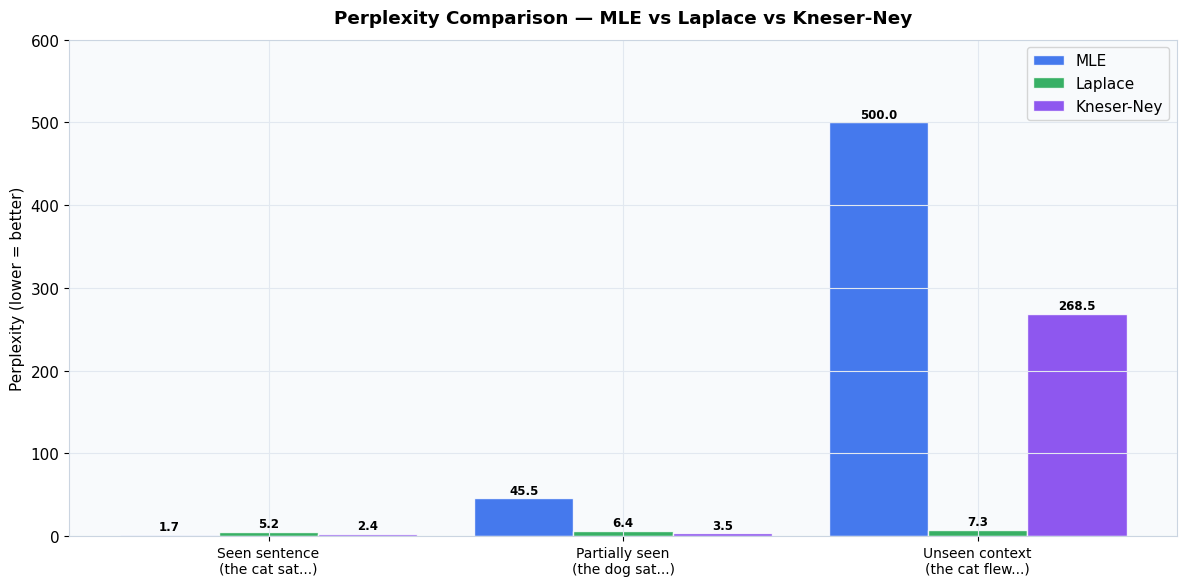

In [31]:
# ── Summary bar chart ────────────────────────────────────────────────────
test_sents = {
    "Seen sentence\n(the cat sat...)" : "<s> the cat sat on the mat </s>",
    "Partially seen\n(the dog sat...)" : "<s> the dog sat on the mat </s>",
    "Unseen context\n(the cat flew...)" : "<s> the cat flew away </s>",
}

results = []
for label, sent in test_sents.items():
    toks = sent.split()
    mle_fn = lambda w, c: mle_bigram_prob(w, c, bigram_counts, unigram_counts)
    lap_fn = lambda w, c: laplace_bigram_prob(w, c, bigram_counts, unigram_counts, vocab)

    try: pp_m = sentence_perplexity(toks, mle_fn, verbose=False)
    except: pp_m = float('inf')

    pp_l = sentence_perplexity(toks, lap_fn, verbose=False)
    pp_k = sentence_perplexity(toks, kn_prob, verbose=False)
    results.append((label, pp_m, pp_l, pp_k))

labels     = [r[0] for r in results]
pp_mle_v   = [min(r[1], 500) for r in results]
pp_lap_v   = [r[2] for r in results]
pp_kn_v    = [r[3] for r in results]

x = np.arange(len(labels)); width = 0.28
fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width, pp_mle_v, width, label="MLE",        color=C["blue"],   alpha=0.85, edgecolor="white")
b2 = ax.bar(x,         pp_lap_v, width, label="Laplace",    color=C["green"],  alpha=0.85, edgecolor="white")
b3 = ax.bar(x + width, pp_kn_v,  width, label="Kneser-Ney", color=C["purple"], alpha=0.85, edgecolor="white")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 2, f"{h:.1f}",
                ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Perplexity (lower = better)")
ax.set_title("Perplexity Comparison — MLE vs Laplace vs Kneser-Ney", fontweight="bold", pad=12)
ax.legend(fontsize=11); ax.set_ylim(0, max(pp_mle_v + pp_lap_v + pp_kn_v) * 1.2)
plt.tight_layout(); plt.savefig("/tmp/perplexity.png", dpi=150, bbox_inches="tight"); plt.show()


## 7. 🛠️ Clean Full Implementation

All three models in tidy classes you can reuse.


In [33]:
class NGramLM:
    """
    General N-gram Language Model supporting:
      - MLE
      - Laplace (Add-k) smoothing
      - Kneser-Ney smoothing (bigram only for clarity)
    """
    def __init__(self, n=2, smoothing="kneser-ney", discount=0.75, k=1):
        self.n         = n
        self.smoothing = smoothing
        self.discount  = discount
        self.k         = k
        self.fitted    = False

    def fit(self, sentences):
        """sentences: list of strings (raw sentences)."""
        tokens = [s.split() for s in sentences]

        self.vocab    = set(w for sent in tokens for w in sent)
        self.V        = len(self.vocab)
        self.ngram_c  = defaultdict(int)
        self.ctx_c    = defaultdict(int)
        self.left_ctx = defaultdict(set)

        for sent in tokens:
            for i in range(len(sent) - 1):
                w_prev, w_curr = sent[i], sent[i+1]
                self.ngram_c[(w_prev, w_curr)] += 1
                self.ctx_c[w_prev] += 1
                self.left_ctx[w_curr].add(w_prev)

        # Continuation counts (KN)
        self.cont_c          = {w: len(ctxs) for w, ctxs in self.left_ctx.items()}
        self.total_cont      = sum(self.cont_c.values())
        self.fitted = True
        return self

    def _p_cont(self, word):
        return self.cont_c.get(word, 0) / self.total_cont if self.total_cont > 0 else 0

    def _lambda(self, context):
        n_types = sum(1 for (c, _) in self.ngram_c if c == context)
        denom   = self.ctx_c.get(context, 0)
        return (self.discount * n_types / denom) if denom > 0 else 0

    def prob(self, word, context):
        assert self.fitted, "Call .fit() first!"
        c_bg  = self.ngram_c.get((context, word), 0)
        c_ctx = self.ctx_c.get(context, 0)

        if self.smoothing == "mle":
            return c_bg / c_ctx if c_ctx > 0 else 0.0

        elif self.smoothing == "laplace":
            return (c_bg + self.k) / (c_ctx + self.k * self.V) if (c_ctx + self.k*self.V) > 0 else 0.0

        elif self.smoothing == "kneser-ney":
            if c_ctx == 0:
                return self._p_cont(word)
            return max(c_bg - self.discount, 0)/c_ctx + self._lambda(context)*self._p_cont(word)

        else:
            raise ValueError(f"Unknown smoothing: {self.smoothing}")

    def perplexity(self, sentence):
        """sentence: raw string, already contains <s> and </s> if desired."""
        toks = sentence.split()
        log_sum, N = 0.0, 0
        for i in range(1, len(toks)):
            p = max(self.prob(toks[i], toks[i-1]), 1e-10)
            log_sum += np.log2(p)
            N += 1
        return 2 ** (-log_sum / N)


# ── Quick demo ──────────────────────────────────────────────────────────────
sents = [
    "<s> the cat sat on the mat </s>",
    "<s> the cat ate the rat </s>",
    "<s> the rat sat on the mat </s>",
    "<s> the dog chased the cat </s>",
    "<s> the cat ran away </s>",
]

models = {
    "MLE"        : NGramLM(smoothing="mle").fit(sents),
    "Laplace"    : NGramLM(smoothing="laplace").fit(sents),
    "Kneser-Ney" : NGramLM(smoothing="kneser-ney").fit(sents),
}

test = "<s> the cat sat on the mat </s>"
print(f"Sentence: {test}")
print(f"{'Model':<15} {'Perplexity':>12}")
print("─" * 30)
for name, model in models.items():
    pp = model.perplexity(test)
    print(f"{name:<13} {pp:>12.4f}")


Sentence: <s> the cat sat on the mat </s>
Model             Perplexity
──────────────────────────────
MLE                 1.6968
Laplace             5.2003
Kneser-Ney          2.3730


## 8. 📊 Summary & Quick Reference

| | **MLE** | **Laplace** | **Kneser-Ney** |
|---|---|---|---|
| **Formula** | C(w,c)/C(c) | (C+1)/(C+V) | discounting + continuation |
| **Zero probs?** | ✅ Yes | ❌ No | ❌ No |
| **Over-smoothing?** | N/A | ⚠️ Yes (too much) | ✅ Mild |
| **Complexity** | O(N) | O(N) | O(N) |
| **Quality** | Baseline | OK | ⭐ State-of-the-art |

### Key Equations Recap

**MLE:**
$$P_{MLE}(w_i|w_{i-1}) = \frac{C(w_{i-1}, w_i)}{C(w_{i-1})}$$

**Laplace:**
$$P_{Lap}(w_i|w_{i-1}) = \frac{C(w_{i-1}, w_i) + 1}{C(w_{i-1}) + V}$$

**Kneser-Ney:**
$$P_{KN}(w_i|w_{i-1}) = \frac{\max(C(w_{i-1},w_i)-d,\;0)}{C(w_{i-1})} + \underbrace{\frac{d \cdot |\text{types after }w_{i-1}|}{C(w_{i-1})}}_{\lambda} \cdot P_{cont}(w_i)$$

$$P_{cont}(w_i) = \frac{|\{v: C(v,w_i)>0\}|}{\sum_w|\{v:C(v,w)>0\}|}$$

**Perplexity:**
$$PP(W) = 2^{-\frac{1}{N}\sum_{i=1}^{N}\log_2 P(w_i|w_{i-1})}$$

---
*Built from scratch — no NLTK LM module used.*
